# End-to-End Machine Learning Project

ML checklist:

1. Look at the big picture and frame the problem.
2. Get the data.
3. Have some insights of the data, and analyse it.
4. Clean the data.
5. Prepare it for the model.
6. Select model.
7. Fine tune the model.
8. Test, Evaluate and improve.
9. Launch!

# Look at the big picture and frame the problem

Ask ques like:

* What we have to finally predict.
* What kind model should we use(supervised/unsupervised/reinforcement), what type of learning/data feeding it is (online/batch) and how the model is learning (instance/model based)
* For what purpose is our prediction going to used
* What are assumptions
* Corrections (loss/cost function used)

Prepare a pipeline:
The pipeline will tell the entire workflow of the project from upstream to downstream

# Get the Data

We can manually go to the website, download & extract the file, and then we can use it in our project.

But it is advisable to make a function with fetches the data, extracts it and import it into our project, as we can use a function multiple times to perform a specific function

## Creating a function to download and extract the file

In [1]:
#intentionally left blank

## Creating a function which imports data into our notebook

In [2]:
import pandas as pd
def ImportData(data_path):
    return pd.read_csv(data_path)

In [3]:
a=ImportData("Concrete_Data_Yeh.csv")
a.sample(5)

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
204,212.1,0.0,121.6,180.3,5.7,1057.6,779.3,3,12.47
819,525.0,0.0,0.0,189.0,0.0,1125.0,613.0,90,58.78
292,182.0,45.2,122.0,170.2,8.2,1059.4,780.7,56,43.50
750,500.0,0.0,0.0,200.0,0.0,1125.0,613.0,28,44.09
562,382.5,0.0,0.0,185.7,0.0,1047.8,739.3,7,24.07


In [4]:
a.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cement            1030 non-null   float64
 1   slag              1030 non-null   float64
 2   flyash            1030 non-null   float64
 3   water             1030 non-null   float64
 4   superplasticizer  1030 non-null   float64
 5   coarseaggregate   1030 non-null   float64
 6   fineaggregate     1030 non-null   float64
 7   age               1030 non-null   int64  
 8   csMPa             1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [5]:
a.describe(include='all')

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


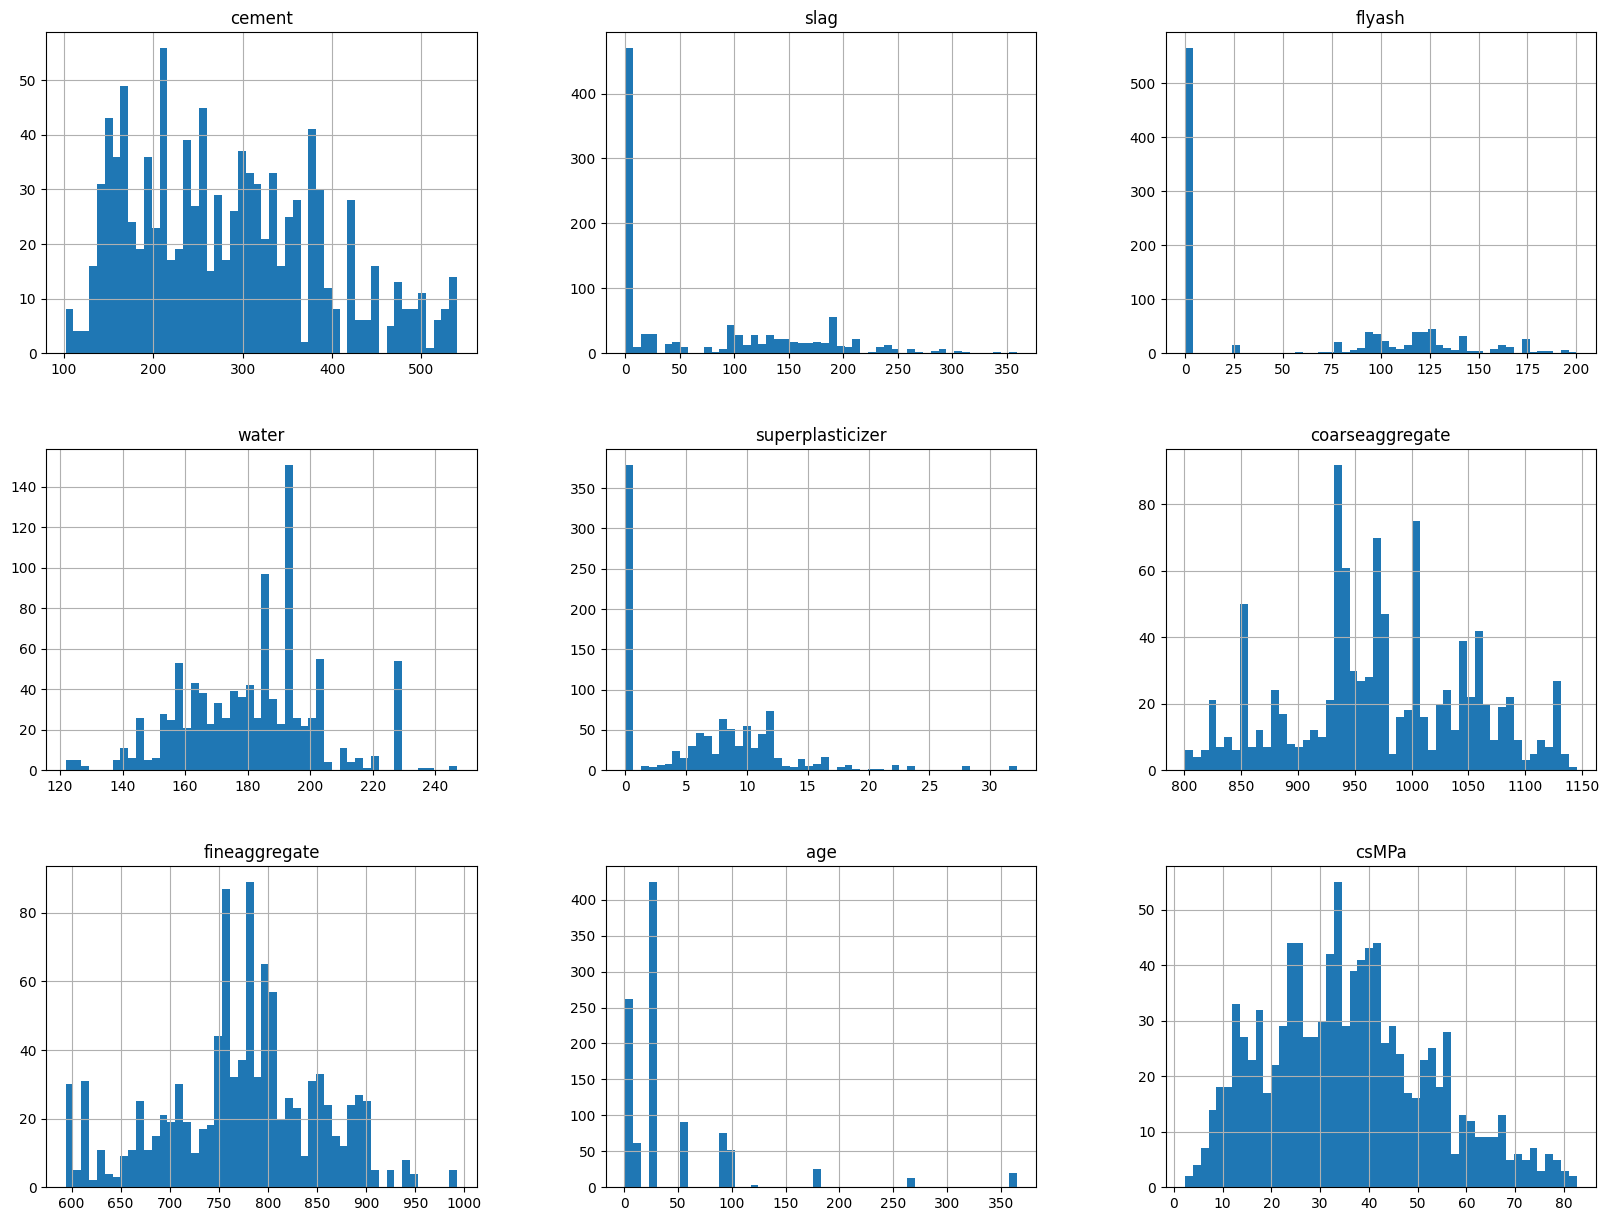

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline
a.hist(bins=50,figsize=(20,15))
plt.show()

# Some insights from the graphs

1. There is no artificial capping in our data.
   In case of capping can follow any of these options: a. get the proper data of capped instaces. b. Remove the capped instances from the data.
2. In some cases our data is tail heavy, like in cement slag flyash and age.

Here are the units of each column:
* Cement: $kg/m^3$
* Blast Furnace Slag: $kg/m^3$
* Fly Ash: $kg/m^3$
* Water: $kg/m^3$
* Superplasticizer: $kg/m^3$
* Coarse Aggregate: $kg/m^3$
* Fine Aggregate: $kg/m^3$
* Age: DaysConcrete Strength: MPa (Megapascals)

# Split the test train data
To do this, we can either write a numpy random code snippet, but the problem will be that every time we rerun that code snippet, the data will be randomly split over test and train, which will eventually, after multiple runs, cause the ML model to 'see' the test data that should not be seen by the model.
This method is shown below & we don't need this code to run this function:

In [7]:
import numpy as np
def split_test_train(data,test_ratio):
    shuffled_indices=np.random.permutation(len(data))
    split_point=int(len(data)*test_ratio)
    test_data=shuffled_indices[:split_point]
    train_data=shuffled_indices[slit_point:]
    return data.iloc[test_data],data.iloc[train_data]

## A correct ways of doing this:
## Method-1
Below is the code snippet with comments showing how to properly split the data

In [8]:
#intentionally left blank

## Method2: Another way to do this is use sklearn's functions

In this code above, the first variable will be assigned the training set and the second one will be assigned a testing set
first argument is the main dataset, test_size is the fraction of testing data, and random_state is the seed, everytime putting this seed/number will generate same sets of training and testing data

In [9]:
from sklearn.model_selection import train_test_split
training_set, testing_set=train_test_split(a,test_size=0.2,random_state=67)

In [10]:
training_set

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
72,425.0,106.3,0.0,153.5,16.5,852.1,887.1,3,33.40
109,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7,55.90
740,297.0,0.0,0.0,186.0,0.0,1040.0,734.0,7,30.96
696,183.9,122.6,0.0,203.5,0.0,959.2,800.0,7,10.79
940,296.0,0.0,106.7,221.4,10.5,819.2,778.4,28,31.42
...,...,...,...,...,...,...,...,...,...
905,135.0,0.0,166.0,180.0,10.0,961.0,805.0,28,13.29
985,255.3,98.8,77.0,188.6,6.5,919.0,749.3,28,33.80
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.45
821,322.0,0.0,0.0,203.0,0.0,974.0,800.0,14,20.77


In [11]:
testing_set

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
487,387.0,20.0,94.0,157.0,11.6,938.0,845.0,28,46.68
114,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7,22.90
458,165.0,0.0,143.6,163.8,0.0,1005.6,900.9,100,37.96
472,446.0,24.0,79.0,162.0,11.6,967.0,712.0,28,44.42
19,475.0,0.0,0.0,228.0,0.0,932.0,594.0,180,42.62
...,...,...,...,...,...,...,...,...,...
491,387.0,20.0,94.0,157.0,14.3,938.0,845.0,7,36.84
289,182.0,45.2,122.0,170.2,8.2,1059.4,780.7,3,7.32
143,375.0,93.8,0.0,126.6,23.4,852.1,992.6,56,60.20
856,356.0,0.0,142.0,193.0,11.0,801.0,778.0,28,40.87


## Method 3: Stratified Sampling
## What is Stratified Sampling?: Another way of using sklearn to split
Stratified sampling is a method where you divide your entire population into homogeneous subgroups (called strata) and then pull the exact right percentage of data from each of those groups to form your final sample.

The classic example: The US population is roughly 51.1% female and 48.9% male. If you conduct a survey of 1,000 people to predict an election, you shouldn't just call 1,000 random phone numbers. By pure chance, you might end up with 450 females and 550 males. Instead, a stratified survey forces the math: you randomly call exactly 511 females and exactly 489 males to perfectly mirror the real world.

## Stratified Sampling
After talking from an expert we came to know that median income is an important attribute while predicting the median house price, as we are doing stratified sampling we need to look at some bins of this attribute.

It is very important for stratified sampling is that we don't have to many startas and each strata is large enough.

In [12]:
#this part is left empty because we don't need to stratified sampling here, just skip to the next part.

Now we will be using these bins in our stratified sampling

Now we will use StratifiedShuffleSplit to split the data.

The section with the largest number of people than other groups got more representation, but random representation from them, this is stratified sampling. Percentage of these categories in the total dataset is:

# Data Exploration-Discover and Visualize the Data to Gain Insights

For exploring the data if the data is very big we take a small chunk out of it and then explore it.
Here our data is quite small so we don't need this.
we will make a copy of the training set so that playing with the copy won't change anything in the original set. Also keep the testing set aside as we will use that set for testing and no instance of that should be involved in training.

In [13]:
#selected training data:
TRAIN=training_set

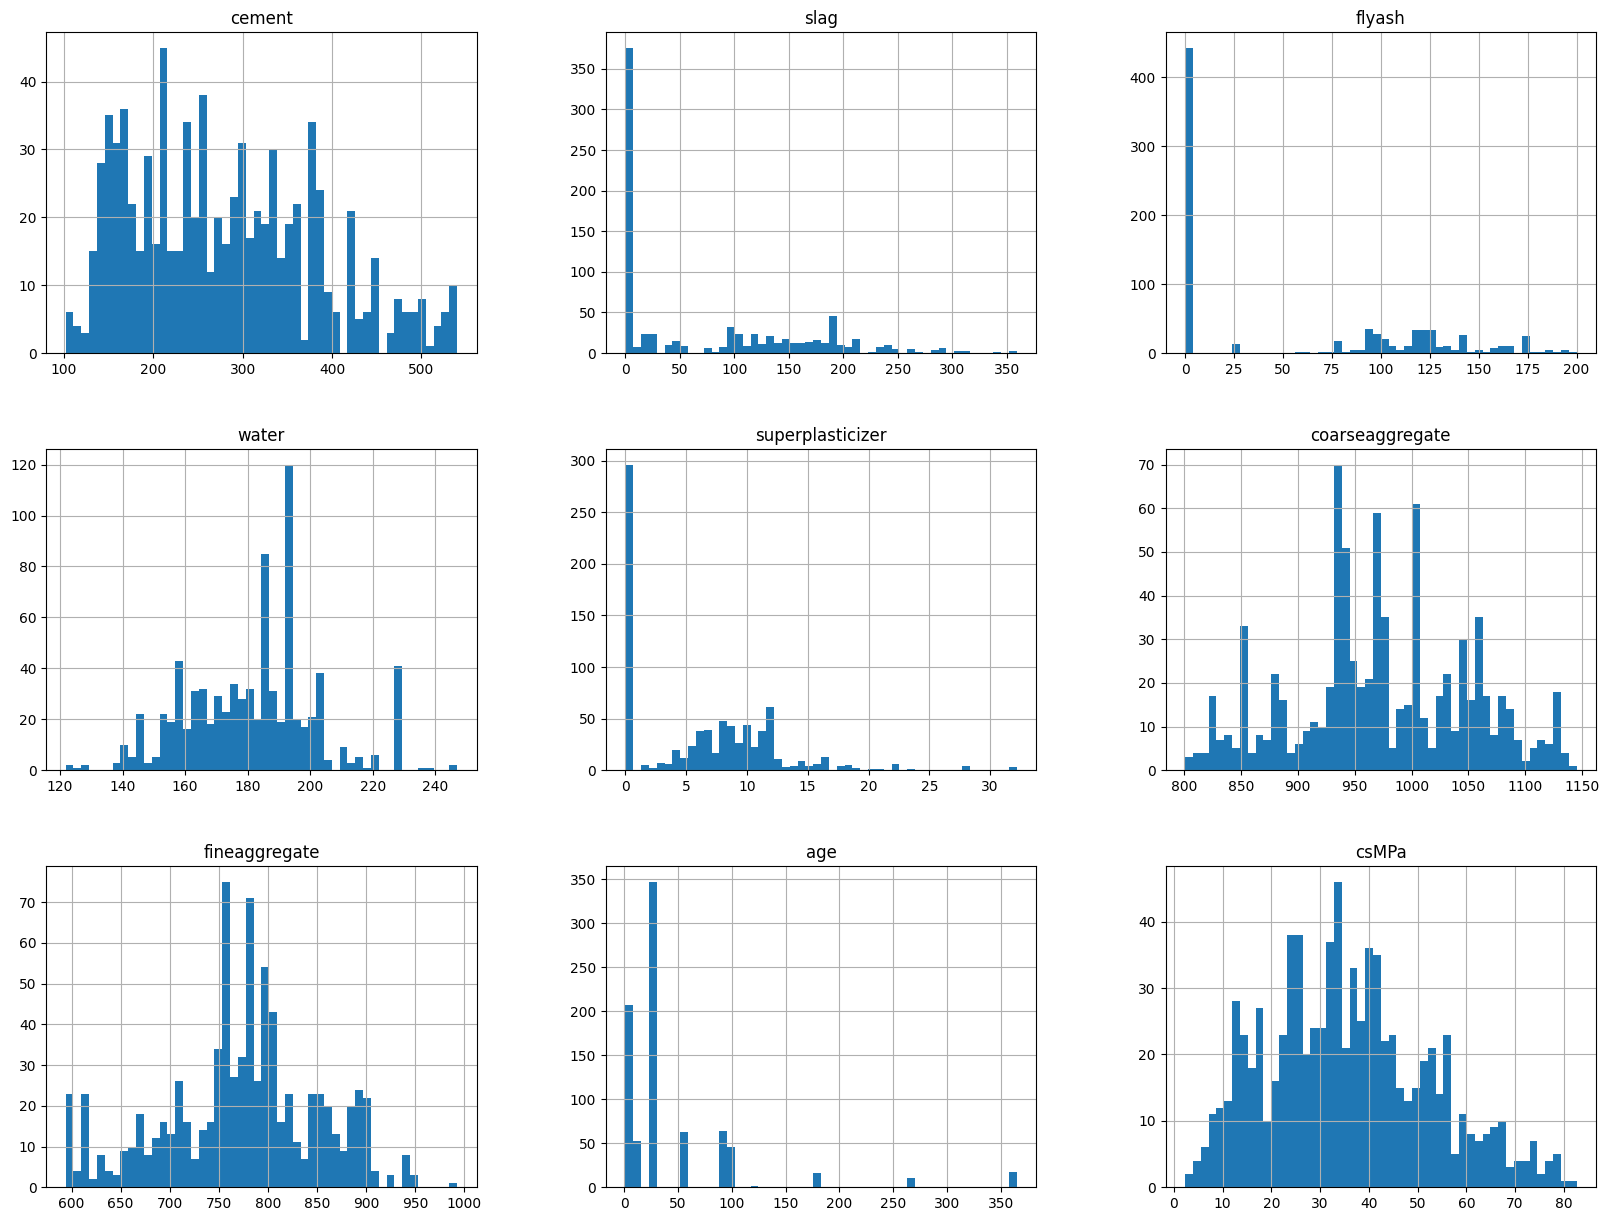

In [14]:
TRAIN.hist(bins=50, figsize=(20,15))
plt.show()

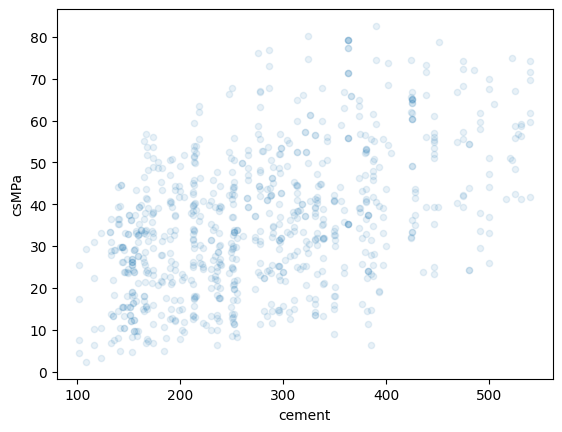

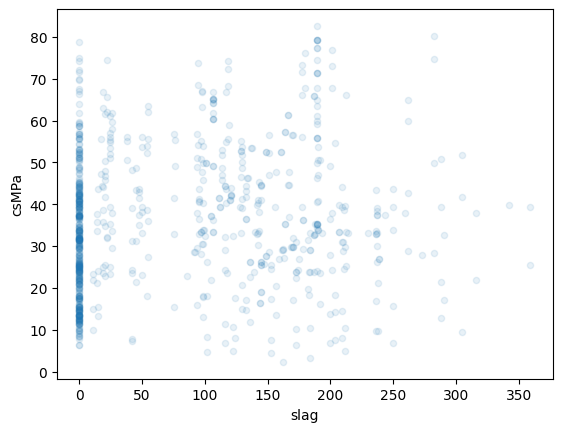

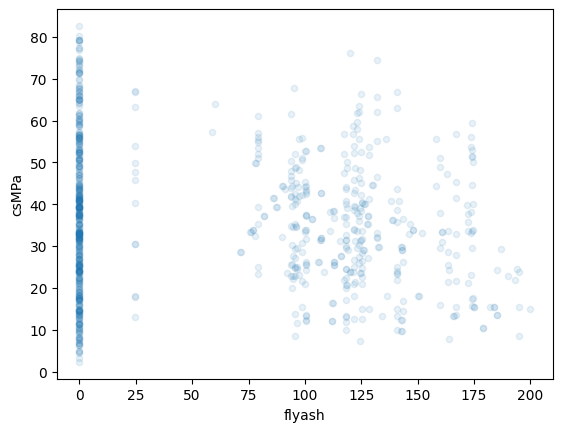

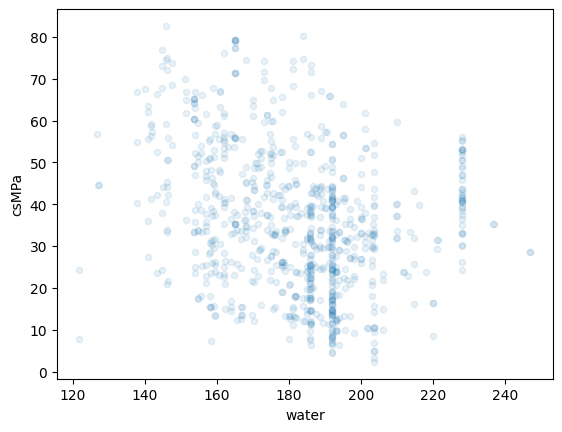

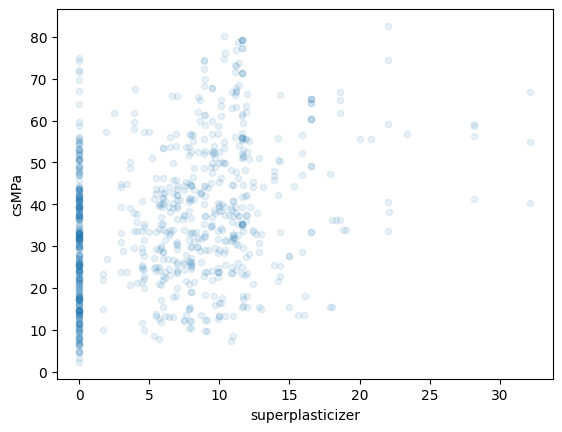

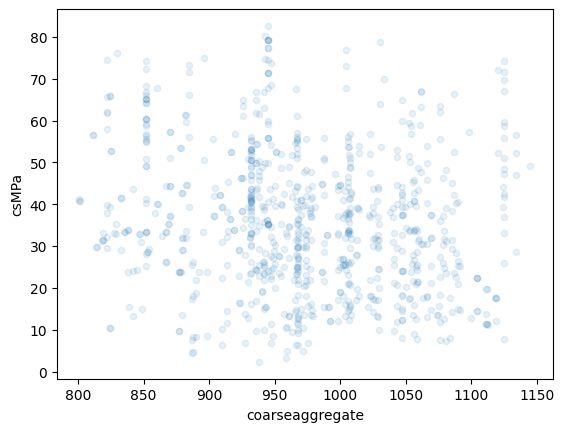

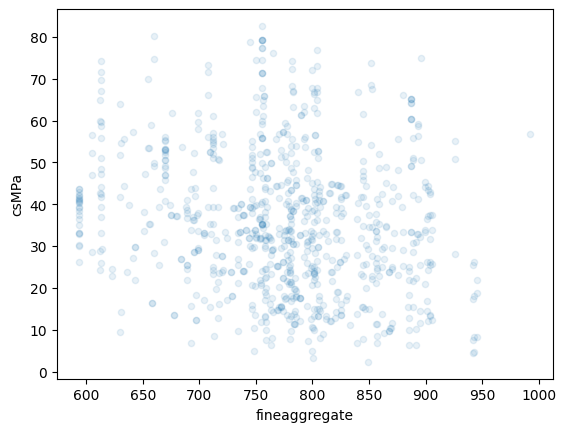

In [15]:
for i in TRAIN.columns[:-2]:
    TRAIN.plot(kind='scatter',x=i,y=a.columns[-1],alpha=0.1)

# Looking for the correlations

A correlation matrix is a giant table (or grid) that calculates the mathematical relationship between every single pair of numerical columns in your dataset. It helps you instantly answer the question: "If one feature goes up, what happens to the other feature?" Each number in it is called the correlation coefficient/Pearson's correlation coefficient.

In [16]:
corr_mat=TRAIN.corr()

In [17]:
corr_mat

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
cement,1.000000,-0.269305,-0.409805,-0.079352,0.074954,-0.089353,-0.227232,0.090167,0.499103
slag,-0.269305,1.000000,-0.319223,0.107806,0.048025,-0.297846,-0.301301,-0.054256,0.151029
flyash,-0.409805,-0.319223,1.000000,-0.254573,0.398885,-0.004410,0.071577,-0.154345,-0.117964
water,-0.079352,0.107806,-0.254573,1.000000,-0.645092,-0.215653,-0.427193,0.285721,-0.272101
superplasticizer,0.074954,0.048025,0.398885,-0.645092,1.000000,-0.232826,0.165115,-0.203151,0.352155
coarseaggregate,-0.089353,-0.297846,-0.004410,-0.215653,-0.232826,1.000000,-0.154403,-0.007065,-0.162588
fineaggregate,-0.227232,-0.301301,0.071577,-0.427193,0.165115,-0.154403,1.000000,-0.155047,-0.194835
age,0.090167,-0.054256,-0.154345,0.285721,-0.203151,-0.007065,-0.155047,1.000000,0.322974
csMPa,0.499103,0.151029,-0.117964,-0.272101,0.352155,-0.162588,-0.194835,0.322974,1.000000


In [18]:
corr_mat['csMPa'].sort_values(ascending=False)

csMPa               1.000000
cement              0.499103
superplasticizer    0.352155
age                 0.322974
slag                0.151029
flyash             -0.117964
coarseaggregate    -0.162588
fineaggregate      -0.194835
water              -0.272101
Name: csMPa, dtype: float64

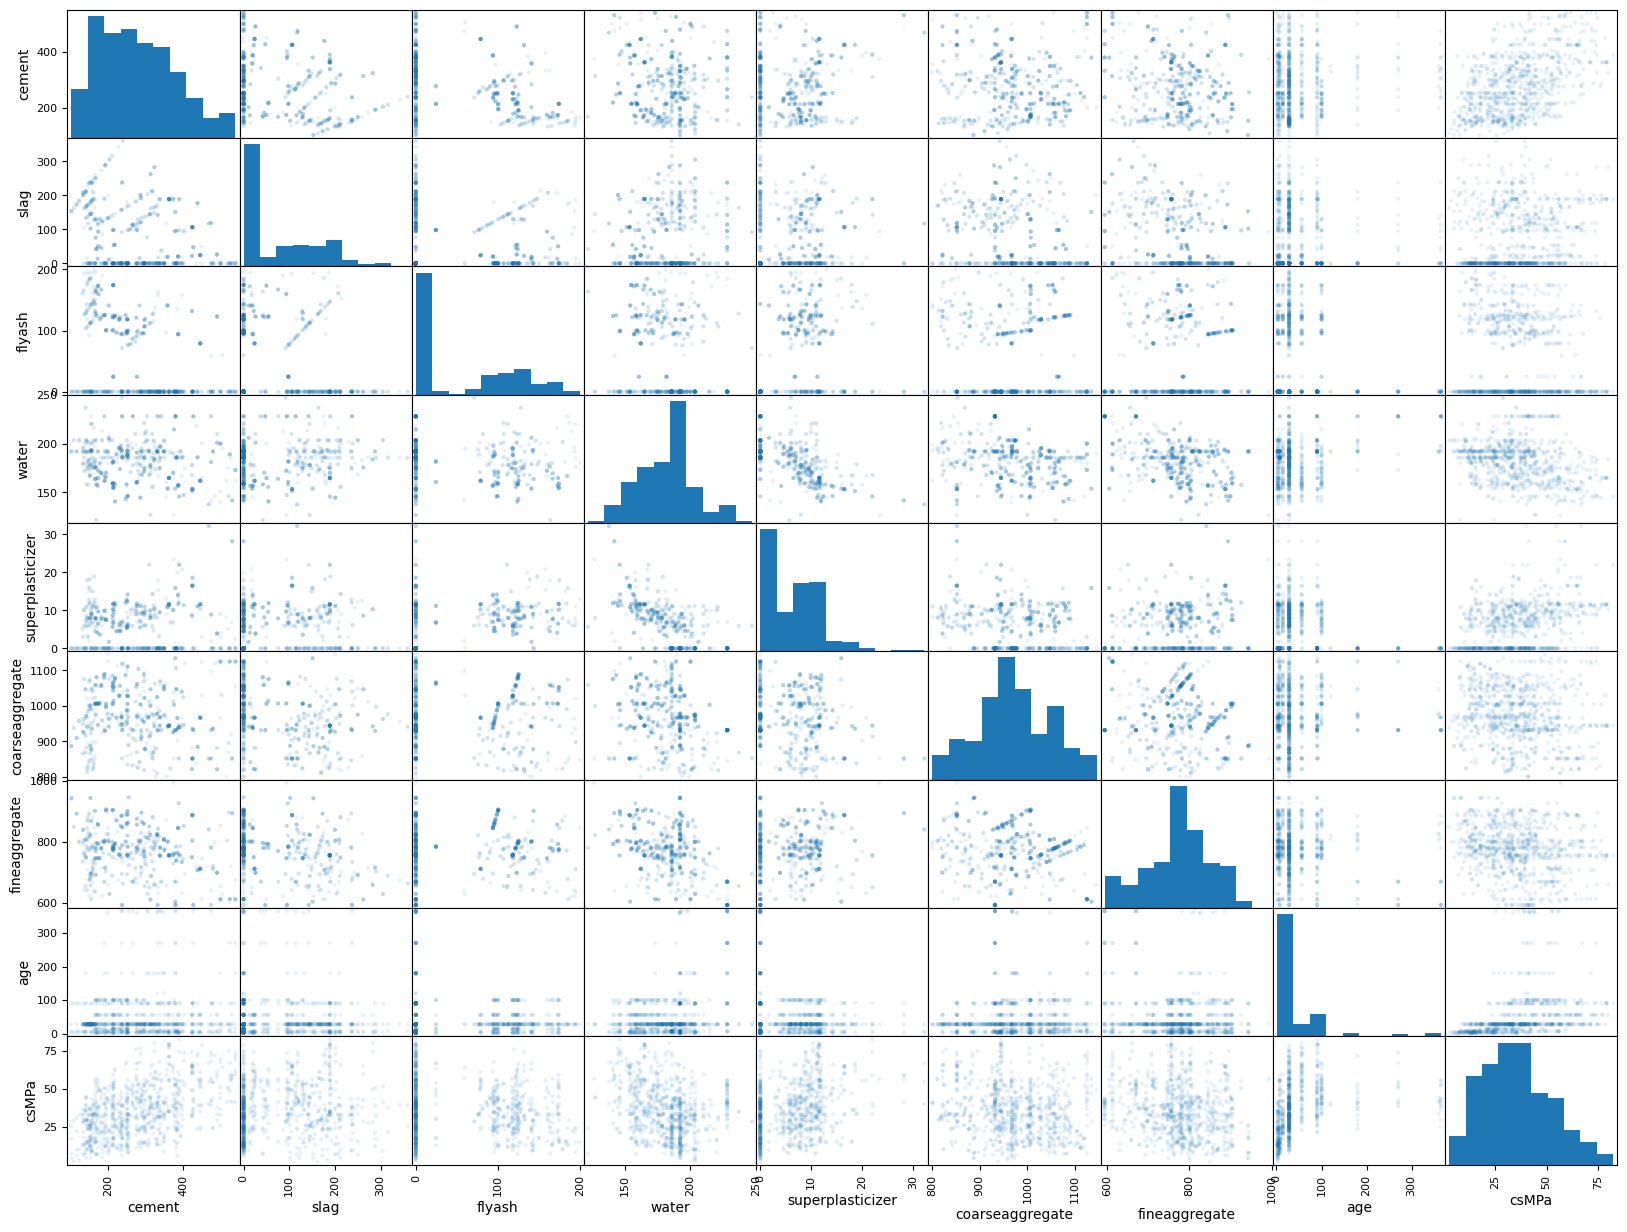

In [19]:
from pandas.plotting import scatter_matrix
scatter_matrix(TRAIN,figsize=(20,15),alpha=0.1)
plt.show()

In [20]:
TRAIN['w/c']=TRAIN['water']/TRAIN['cement']
TRAIN['total_binder']=TRAIN['cement']+TRAIN['slag']+TRAIN['flyash']
TRAIN['log(age)']=np.log(TRAIN['age'])
TRAIN['fine/coarse']=TRAIN['fineaggregate']/TRAIN['coarseaggregate']

In [21]:
TRAIN

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa,w/c,total_binder,log(age),fine/coarse
72,425.0,106.3,0.0,153.5,16.5,852.1,887.1,3,33.40,0.361176,531.3,1.098612,1.041075
109,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7,55.90,0.454771,551.6,1.945910,0.800042
740,297.0,0.0,0.0,186.0,0.0,1040.0,734.0,7,30.96,0.626263,297.0,1.945910,0.705769
696,183.9,122.6,0.0,203.5,0.0,959.2,800.0,7,10.79,1.106580,306.5,1.945910,0.834028
940,296.0,0.0,106.7,221.4,10.5,819.2,778.4,28,31.42,0.747973,402.7,3.332205,0.950195
...,...,...,...,...,...,...,...,...,...,...,...,...,...
905,135.0,0.0,166.0,180.0,10.0,961.0,805.0,28,13.29,1.333333,301.0,3.332205,0.837669
985,255.3,98.8,77.0,188.6,6.5,919.0,749.3,28,33.80,0.738739,431.1,3.332205,0.815343
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.45,0.600000,475.0,3.332205,0.637339
821,322.0,0.0,0.0,203.0,0.0,974.0,800.0,14,20.77,0.630435,322.0,2.639057,0.821355


In [22]:
corr_mat=TRAIN.corr()
corr_mat['csMPa'].sort_values(ascending=False)

csMPa               1.000000
total_binder        0.618864
log(age)            0.549304
cement              0.499103
superplasticizer    0.352155
age                 0.322974
slag                0.151029
fine/coarse        -0.039859
flyash             -0.117964
coarseaggregate    -0.162588
fineaggregate      -0.194835
water              -0.272101
w/c                -0.497939
Name: csMPa, dtype: float64

In [23]:
#total_binder and log(age) has a strong positive correlation while w/c has a strong negative correlation, while fine/coarse is not much related


In [24]:
TRAIN.drop(columns=['fine/coarse'], inplace=True)

In [25]:
TARGET=TRAIN['csMPa']
TRAIN.drop(columns=['csMPa'],inplace=True)

In [26]:
TARGET

72     33.40
109    55.90
740    30.96
696    10.79
940    31.42
       ...  
905    13.29
985    33.80
7      36.45
821    20.77
835    15.42
Name: csMPa, Length: 824, dtype: float64

In [27]:
TRAIN.columns


Index(['cement', 'slag', 'flyash', 'water', 'superplasticizer',
       'coarseaggregate', 'fineaggregate', 'age', 'w/c', 'total_binder',
       'log(age)'],
      dtype='str')

## Cleaning Data

Generallu in cleaning data we check for NaN/missing values, capped attributes, handling capped attributes, feature scaling etc.

Incase of missing values you have three options:
1. Get rid of the corresponding districts.
2. Get rid of the whole attribute.
3. Set the values to some value (zero, the mean, the median, etc.).


TRAIN.dropna(subset=["write the column with NA"]) # option 1

TRAIN.drop("col with NA", axis=1) # option 2

median = TARGET.median() # option 3

TRAIN["col with NA"].fillna(median, inplace=True)


In [28]:
TEST=testing_set
TEST['w/c']=TEST['water']/TEST['cement']
TEST['total_binder']=TEST['cement']+TEST['slag']+TEST['flyash']
TEST['log(age)']=np.log(TEST['age'])
TEST

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa,w/c,total_binder,log(age)
487,387.0,20.0,94.0,157.0,11.6,938.0,845.0,28,46.68,0.405685,501.0,3.332205
114,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7,22.90,0.454771,551.6,1.945910
458,165.0,0.0,143.6,163.8,0.0,1005.6,900.9,100,37.96,0.992727,308.6,4.605170
472,446.0,24.0,79.0,162.0,11.6,967.0,712.0,28,44.42,0.363229,549.0,3.332205
19,475.0,0.0,0.0,228.0,0.0,932.0,594.0,180,42.62,0.480000,475.0,5.192957
...,...,...,...,...,...,...,...,...,...,...,...,...
491,387.0,20.0,94.0,157.0,14.3,938.0,845.0,7,36.84,0.405685,501.0,1.945910
289,182.0,45.2,122.0,170.2,8.2,1059.4,780.7,3,7.32,0.935165,349.2,1.098612
143,375.0,93.8,0.0,126.6,23.4,852.1,992.6,56,60.20,0.337600,468.8,4.025352
856,356.0,0.0,142.0,193.0,11.0,801.0,778.0,28,40.87,0.542135,498.0,3.332205


In [29]:
'csMPa' in TRAIN

False

# FEATURE SCALING

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [31]:
num_pipeline = Pipeline([
 ('imputer', SimpleImputer(strategy="median")),
 ('std_scaler', StandardScaler()),
 ])

In [32]:
train_arr=num_pipeline.fit_transform(TRAIN)

In [33]:
TARGET

72     33.40
109    55.90
740    30.96
696    10.79
940    31.42
       ...  
905    13.29
985    33.80
7      36.45
821    20.77
835    15.42
Name: csMPa, Length: 824, dtype: float64

In [34]:
from sklearn.linear_model import LinearRegression

In [35]:
linReg=LinearRegression()

In [36]:
linReg.fit(train_arr,TARGET)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [37]:
example=train_arr[1:7,:]
example_output=TARGET[1:7]
linReg.predict(example)

array([46.16323244, 13.86650657,  9.76058412, 29.41683912, 50.0755534 ,
       19.79356487])

In [38]:
example_output

109    55.90
740    30.96
696    10.79
940    31.42
56     41.93
666    12.79
Name: csMPa, dtype: float64

In [39]:
from sklearn.metrics import mean_squared_error
output=linReg.predict(train_arr)
lin_mse=mean_squared_error(output,TARGET)
error=np.sqrt(lin_mse)
error

np.float64(6.812657694549698)

In [40]:
from sklearn.tree import DecisionTreeRegressor
dtr=DecisionTreeRegressor(max_depth=8)
dtr.fit(train_arr,TARGET)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

In [41]:
example=train_arr[1:7,:]
example_output=TARGET[1:7]
dtr.predict(example)

array([56.578     , 30.96      , 11.256     , 34.35888889, 42.88      ,
       15.56857143])

In [42]:
example_output

109    55.90
740    30.96
696    10.79
940    31.42
56     41.93
666    12.79
Name: csMPa, dtype: float64

In [43]:
outputdtr=dtr.predict(train_arr)
mse=mean_squared_error(outputdtr,TARGET)
rmse=np.sqrt(mse)
rmse

np.float64(3.431829924825316)

In [44]:
from sklearn.model_selection import cross_val_score
score=cross_val_score(dtr,train_arr,TARGET,scoring="neg_mean_squared_error",cv=10)
score=np.sqrt(-score)

In [45]:
np.mean(score)

np.float64(6.397196447224994)

In [46]:
from sklearn.ensemble import RandomForestRegressor
rfr=RandomForestRegressor(random_state=67)
rfr.fit(train_arr,TARGET)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [47]:
outputrfr=rfr.predict(train_arr)
mse=mean_squared_error(outputrfr,TARGET)
rmse=np.sqrt(mse)
rmse

np.float64(1.772047137261997)

In [48]:
score=cross_val_score(rfr,train_arr,TARGET,scoring="neg_mean_squared_error",cv=10)
score=np.sqrt(-score)
np.mean(score)

np.float64(4.69678523668573)

In [49]:
score=cross_val_score(linReg,train_arr,TARGET,scoring='neg_mean_squared_error',cv=10)
score=np.sqrt(-score)
np.mean(score)

np.float64(6.935372500540398)

## Fine tuning the model

In [50]:
param_grid = [
{'n_estimators': [3, 10, 100], 'max_features': [2, 4, 6, 8]},
{'bootstrap': [False], 'n_estimators': [3, 10,100], 'max_features': [2, 3, 4]},
]  #example

In [51]:
from sklearn.model_selection import GridSearchCV
rfr=RandomForestRegressor()
grid_search=GridSearchCV(rfr,param_grid,cv=5,scoring='neg_mean_squared_error',
return_train_score=True)
grid_search.fit(train_arr,TARGET)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'max_features': [2, 4, ...], 'n_estimators': [3, 10, ...]}, {'bootstrap': [False], 'max_features': [2, 3, ...], 'n_estimators': [3, 10, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computat

In [52]:
rfr=RandomForestRegressor(n_estimators=100,max_features=2,bootstrap=False,random_state=67)

In [53]:
rfr.fit(train_arr,TARGET)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",2
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [54]:
outputrfr=rfr.predict(train_arr)
mse=mean_squared_error(outputrfr,TARGET)
rmse=np.sqrt(mse)
rmse

np.float64(0.5028247299138587)

In [55]:
score=cross_val_score(rfr,train_arr,TARGET,scoring='neg_mean_squared_error',cv=10)
score=np.mean(np.sqrt(-score))
score

np.float64(4.289358550349031)

# Final testing set

In [56]:
TEST

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa,w/c,total_binder,log(age)
487,387.0,20.0,94.0,157.0,11.6,938.0,845.0,28,46.68,0.405685,501.0,3.332205
114,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7,22.90,0.454771,551.6,1.945910
458,165.0,0.0,143.6,163.8,0.0,1005.6,900.9,100,37.96,0.992727,308.6,4.605170
472,446.0,24.0,79.0,162.0,11.6,967.0,712.0,28,44.42,0.363229,549.0,3.332205
19,475.0,0.0,0.0,228.0,0.0,932.0,594.0,180,42.62,0.480000,475.0,5.192957
...,...,...,...,...,...,...,...,...,...,...,...,...
491,387.0,20.0,94.0,157.0,14.3,938.0,845.0,7,36.84,0.405685,501.0,1.945910
289,182.0,45.2,122.0,170.2,8.2,1059.4,780.7,3,7.32,0.935165,349.2,1.098612
143,375.0,93.8,0.0,126.6,23.4,852.1,992.6,56,60.20,0.337600,468.8,4.025352
856,356.0,0.0,142.0,193.0,11.0,801.0,778.0,28,40.87,0.542135,498.0,3.332205


In [57]:
test=TEST.drop('csMPa',axis=1)
target=TEST['csMPa'].copy()

In [58]:
test_arr=num_pipeline.transform(test)

In [59]:
Final_Test=rfr.predict(test_arr)

In [60]:
mse=mean_squared_error(Final_Test,target)

In [61]:
score=np.sqrt(mse)
score

np.float64(4.9577523151155845)

In [62]:
import joblib
joblib.dump(rfr,"ConcreteStrengthPrediction.pkl")
joblib.dump(num_pipeline, "num_pipeline.pkl")

['num_pipeline.pkl']